100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]



=== Training with λ = 1e-05 ===
[λ=1e-05] Epoch 1: Acc=47.07%, Sparsity=0.00%
[λ=1e-05] Epoch 2: Acc=50.08%, Sparsity=0.02%
[λ=1e-05] Epoch 3: Acc=53.14%, Sparsity=0.07%
[λ=1e-05] Epoch 4: Acc=54.30%, Sparsity=0.20%
[λ=1e-05] Epoch 5: Acc=55.14%, Sparsity=0.48%
[λ=1e-05] Epoch 6: Acc=54.92%, Sparsity=1.02%
[λ=1e-05] Epoch 7: Acc=55.41%, Sparsity=1.92%
[λ=1e-05] Epoch 8: Acc=56.00%, Sparsity=3.30%
[λ=1e-05] Epoch 9: Acc=56.03%, Sparsity=5.27%
[λ=1e-05] Epoch 10: Acc=56.24%, Sparsity=7.81%

=== Training with λ = 0.0001 ===
[λ=0.0001] Epoch 1: Acc=45.77%, Sparsity=0.00%
[λ=0.0001] Epoch 2: Acc=50.00%, Sparsity=0.03%
[λ=0.0001] Epoch 3: Acc=52.32%, Sparsity=0.16%
[λ=0.0001] Epoch 4: Acc=53.45%, Sparsity=0.52%
[λ=0.0001] Epoch 5: Acc=53.95%, Sparsity=1.46%
[λ=0.0001] Epoch 6: Acc=54.43%, Sparsity=3.47%
[λ=0.0001] Epoch 7: Acc=54.99%, Sparsity=7.27%
[λ=0.0001] Epoch 8: Acc=55.36%, Sparsity=13.65%
[λ=0.0001] Epoch 9: Acc=55.38%, Sparsity=23.43%
[λ=0.0001] Epoch 10: Acc=56.04%, Sparsity=36.69

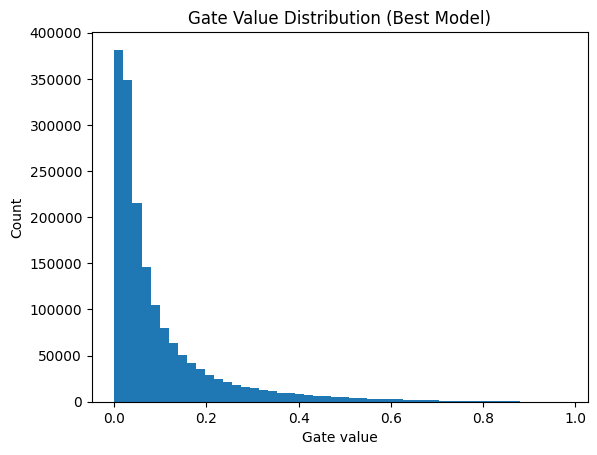

In [ ]:
# self_pruning_cifar10.py
# -------------------------------------------------------
# Self-pruning MLP on CIFAR-10 using learnable gates + L1 sparsity
# -------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------------
# 1. Prunable Linear Layer
# -------------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)     # [0,1]
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

# -------------------------------
# 2. Model (MLP)
# -------------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# -------------------------------
# 3. Data
# -------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 4. Helpers
# -------------------------------
def compute_sparsity(model, threshold=1e-2):
    total, zero = 0, 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            g = torch.sigmoid(m.gate_scores)
            total += g.numel()
            zero  += (g < threshold).sum().item()
    return 100.0 * zero / total

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return 100.0 * correct / total

def train_one_lambda(lambda_val, epochs=10, lr=1e-3):
    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            cls_loss = criterion(outputs, labels)

            # L1 sparsity on gates
            sparsity_loss = 0.0
            for m in model.modules():
                if isinstance(m, PrunableLinear):
                    gates = torch.sigmoid(m.gate_scores)
                    sparsity_loss += gates.sum()

            loss = cls_loss + lambda_val * sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc = evaluate(model)
        sp  = compute_sparsity(model)
        print(f"[λ={lambda_val}] Epoch {epoch+1}: Acc={acc:.2f}%, Sparsity={sp:.2f}%")

    final_acc = evaluate(model)
    final_sp  = compute_sparsity(model)

    return model, final_acc, final_sp

# -------------------------------
# 5. Run experiments
# -------------------------------
lambdas = [1e-5, 1e-4, 1e-3]
results = []

best_model = None
best_score = -1

for lam in lambdas:
    print(f"\n=== Training with λ = {lam} ===")
    model, acc, sp = train_one_lambda(lam, epochs=10)
    results.append((lam, acc, sp))

    # choose "best" by a simple combined score (you can justify this)
    score = acc - 0.1 * sp
    if score > best_score:
        best_score = score
        best_model = model

# -------------------------------
# 6. Print table
# -------------------------------
print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")
for lam, acc, sp in results:
    print(f"{lam}\t{acc:.2f}%\t\t{sp:.2f}%")

# -------------------------------
# 7. Plot gate distribution
# -------------------------------
all_gates = []
for m in best_model.modules():
    if isinstance(m, PrunableLinear):
        g = torch.sigmoid(m.gate_scores).detach().cpu().numpy()
        all_gates.extend(g.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution (Best Model)")
plt.xlabel("Gate value")
plt.ylabel("Count")
plt.show()